# MFPT Table Printer

This notebook prints `t = <T(n0)>` over a grid of `m0` and `r` values using the spectral Julia MFPT routine, with no comparisons or plots.

In [5]:
using Printf

candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting
println("Loaded VoterResetting from: $(project_root)")

Loaded VoterResetting from: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\


In [6]:
N = 500
m0_values = collect(0.0:0.1:0.9)
r_values = collect(range(0.0, 0.95, length = 20))
precision_bits = 128

println("m0\tr\tt")
println(repeat("-", 64))
for m0 in m0_values
    for r in r_values
        n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
        t = VR.exact_mfpt_discrete_spectral(N, n0, r; precision_bits = precision_bits, return_bigfloat = false)
        @printf("%.1f\t%.6f\t%.16e\n", m0, r, t)
    end
end

m0	r	t
----------------------------------------------------------------
0.0	0.000000	1.7269097104920755e+05
0.0	0.050000	4.2914351111891894e+06
0.0	0.100000	4.5930459558348805e+07
0.0	0.150000	3.2846242970667595e+08
0.0	0.200000	1.8371160336552529e+09
0.0	0.250000	8.6676093554147625e+09
0.0	0.300000	3.6017273048170692e+10
0.0	0.350000	1.3547674006702827e+11
0.0	0.400000	4.6997920227245819e+11
0.0	0.450000	1.5240247171661423e+12
0.0	0.500000	4.6663662881190186e+12
0.0	0.550000	1.3596521056293887e+13
0.0	0.600000	3.7936197767134469e+13
0.0	0.650000	1.0189034544956514e+14
0.0	0.700000	2.6469042384407125e+14
0.0	0.750000	6.6846340455814988e+14
0.0	0.800000	1.6524963175675665e+15
0.0	0.850000	4.0470371993852375e+15
0.0	0.900000	1.0073934747754560e+16
0.0	0.950000	2.7257988400021860e+16
0.1	0.000000	1.7144138688128040e+05
0.1	0.050000	3.8046992081189919e+06
0.1	0.100000	3.6435747178890832e+07
0.1	0.150000	2.3478143469256142e+08
0.1	0.200000	1.1905340873285329e+09
0.1	0.250000	5.1197545697053

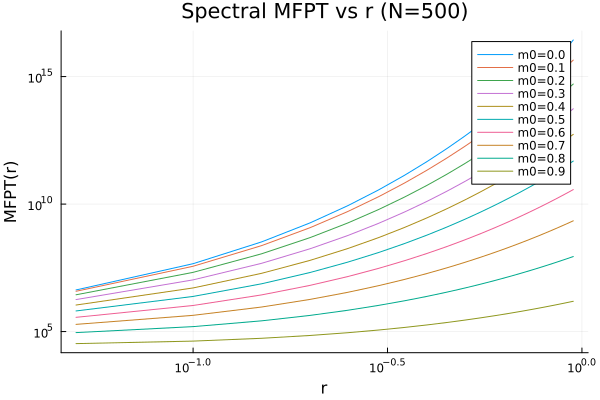

In [15]:
using Plots

gr()

p = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Spectral MFPT vs r (N=$(N))",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    linewidth = 2,
)

for m0 in m0_values
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    t_values = [
        VR.exact_mfpt_discrete_spectral(
            N,
            n0,
            r;
            precision_bits = precision_bits,
            return_bigfloat = false,
        ) for r in r_values
    ]

    mask = isfinite.(t_values) .& (t_values .> 0.0) .& (r_values .> 0)
    rr = r_values[mask]
    tt = t_values[mask]
    isempty(tt) && continue

    plot!(p, rr, tt, label = @sprintf("m0=%.1f", m0))
end

p

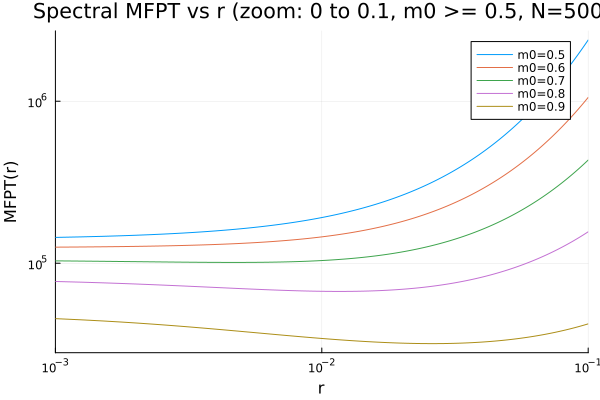

In [17]:
r_zoom = collect(range(0.0, 0.1, length = 400))
m0_zoom_values = filter(m0 -> m0 >= 0.5, m0_values)

p_zoom = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Spectral MFPT vs r (zoom: 0 to 0.1, m0 >= 0.5, N=$(N))",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    linewidth = 2,
    xlims = (0.001, 0.1),
)

for m0 in m0_zoom_values
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    t_zoom = [
        VR.exact_mfpt_discrete_spectral(
            N,
            n0,
            r;
            precision_bits = precision_bits,
            return_bigfloat = false,
        ) for r in r_zoom
    ]

    mask = isfinite.(t_zoom) .& (t_zoom .> 0.0) .& (r_zoom .> 0)
    rr = r_zoom[mask]
    tt = t_zoom[mask]
    isempty(tt) && continue

    plot!(p_zoom, rr, tt, label = @sprintf("m0=%.1f", m0))
end

p_zoom

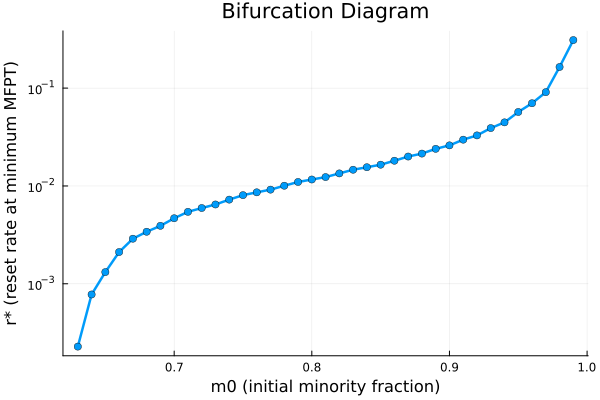

In [28]:
using Optim

# For each m0, find the r value that minimizes MFPT
# Fine grid from m0=0.5 to m0≈1 to resolve bifurcation
m0_fine = collect(0.63:0.01:0.99)  # fine m0 grid focusing on bifurcation region
r_minima = Float64[]
mfpt_minima = Float64[]

for m0 in m0_fine
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    
    # Objective function: MFPT as a function of r
    # Use adaptive search: first coarse, then fine
    function mfpt_func(r)
        if r < 0 || r >= 1
            return 1e10  # penalty
        end
        t = VR.exact_mfpt_discrete_spectral(N, n0, r; precision_bits=precision_bits, return_bigfloat=false)
        return isfinite(t) && t > 0 ? t : 1e10
    end
    
    # First: coarse search to find approximate minimum location
    r_coarse = collect(range(0.0, min(0.3, 0.95), length=100))
    t_coarse = [mfpt_func(r) for r in r_coarse]
    
    valid_idx = findall(x -> isfinite(x) && x < 1e10, t_coarse)
    if isempty(valid_idx)
        continue  # skip if no valid points
    end
    
    # Find the r with minimum MFPT in coarse search
    min_coarse_idx = valid_idx[argmin(t_coarse[valid_idx])]
    r_approx = r_coarse[min_coarse_idx]
    
    # Second: fine search using Optim around the approximate minimum
    # Define a local search interval around the found minimum
    r_lower = max(0.0, r_approx - 0.01)
    r_upper = min(0.95, r_approx + 0.01)
    
    if r_upper > r_lower
        result = optimize(mfpt_func, r_lower, r_upper)
        r_min = Optim.minimizer(result)
        t_min = Optim.minimum(result)
    else
        r_min = r_approx
        t_min = mfpt_func(r_approx)
    end
    
    if isfinite(t_min) && t_min < 1e10
        push!(r_minima, r_min)
        push!(mfpt_minima, t_min)
    else
        push!(r_minima, NaN)
        push!(mfpt_minima, NaN)
    end
end

# Filter for valid points (nonzero and finite) for log-log plot
valid_mask = (m0_fine .> 0) .& isfinite.(r_minima) .& (r_minima .> 0)
m0_plot = m0_fine[valid_mask]
r_plot = r_minima[valid_mask]

# Create bifurcation diagram (log-log scale)
p_bifurc = plot(
    m0_plot,
    r_plot,
    xlabel="m0 (initial minority fraction)",
    ylabel="r* (reset rate at minimum MFPT)",
    title="Bifurcation Diagram",
    legend=false,
    linewidth=2.5,
    markerstrokewidth=0.5,
    markersize=4,
    marker=:circle,
    # xscale=:log10,
    yscale=:log10,
)

p_bifurc

In [24]:
# Summary table of bifurcation points
println("\n" * repeat("=", 70))
println("BIFURCATION DIAGRAM: Minimum Location Summary")
println(repeat("=", 70))
println(@sprintf("%8s | %12s | %12s", "m0", "r* (min loc)", "MFPT(r*)"))
println(repeat("-", 70))

for (m0, r_min, t_min) in zip(m0_fine, r_minima, mfpt_minima)
    if isfinite(r_min) && isfinite(t_min)
        println(@sprintf("%8.3f | %12.6e | %12.6e", m0, r_min, t_min))
    else
        println(@sprintf("%8.3f | %12s | %12s", m0, "N/A", "N/A"))
    end
end
println(repeat("=", 70))

# Identify bifurcation point
bifurc_idx = findfirst(r -> isfinite(r) && r > 1e-6, r_minima)
if bifurc_idx !== nothing
    bifurc_m0 = m0_fine[bifurc_idx]
    println("\n✓ Bifurcation onset detected at m0 ≈ $(bifurc_m0)")
else
    println("\n✓ No clear bifurcation detected in m0 range")
end


BIFURCATION DIAGRAM: Minimum Location Summary
      m0 | r* (min loc) |     MFPT(r*)
----------------------------------------------------------------------
   0.500 | 4.214936e-16 | 1.400535e+05
   0.510 | 4.214936e-16 | 1.383848e+05
   0.520 | 4.214936e-16 | 1.372453e+05
   0.530 | 4.214936e-16 | 1.360840e+05
   0.540 | 4.214936e-16 | 1.343003e+05
   0.550 | 4.214936e-16 | 1.324660e+05
   0.560 | 4.214936e-16 | 1.312144e+05
   0.570 | 4.214936e-16 | 1.299396e+05
   0.580 | 4.214936e-16 | 1.279831e+05
   0.590 | 4.214936e-16 | 1.266488e+05
   0.600 | 4.214936e-16 | 1.246013e+05
   0.610 | 4.214936e-16 | 1.232053e+05
   0.620 | 4.214936e-16 | 1.210636e+05
   0.630 | 2.279834e-04 | 1.188518e+05
   0.640 | 7.775209e-04 | 1.172300e+05
   0.650 | 1.317135e-03 | 1.154601e+05
   0.660 | 2.110948e-03 | 1.125563e+05
   0.670 | 2.890053e-03 | 1.093899e+05
   0.680 | 3.403500e-03 | 1.071517e+05
   0.690 | 3.913742e-03 | 1.048234e+05
   0.700 | 4.676085e-03 | 1.011826e+05
   0.710 | 5.439062e-03 


FINITE-SIZE CHECK: estimated critical m0 vs system size N
       N |        m0_crit
------------------------------------------------------------------------------
     100 |       0.630000
     150 |       0.620000
     200 |       0.630000
     250 |       0.630000
     300 |       0.640000
     400 |       0.630000
     500 |       0.630000
     600 |       0.630000
     700 |       0.640000
     800 |       0.630000
    1000 |       0.630000
    1200 |       0.630000
    1500 |       0.640000


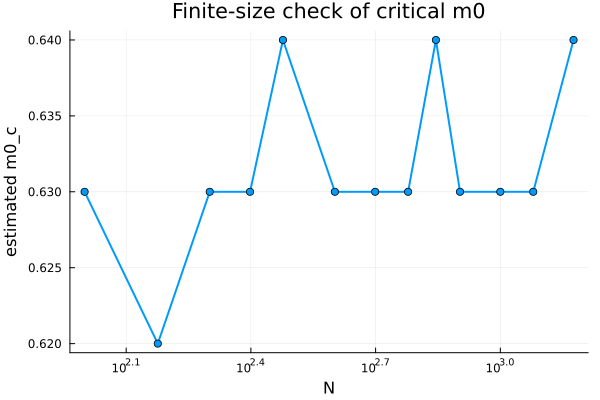

In [ ]:
# Finite-size check: estimate the critical m0 for several system sizes N
N_values = collect(100:100:10000)
m0_grid = unique(sort(vcat(
    collect(0.50:0.01:0.54),
    collect(0.54:0.005:0.70),
)))
r_threshold = 1e-6

function estimate_critical_m0_for_N(N_current, m0_grid; r_threshold = 1e-6)
    r_minima_local = Float64[]

    for m0 in m0_grid
        n0 = clamp(round(Int, N_current * (1 + m0) / 2), 1, N_current - 1)

        function mfpt_func(r)
            if r < 0 || r >= 1
                return 1e10
            end
            t = VR.exact_mfpt_discrete_spectral(N_current, n0, r; precision_bits = precision_bits, return_bigfloat = false)
            return isfinite(t) && t > 0 ? t : 1e10
        end

        r_coarse = collect(range(0.0, min(0.3, 0.95), length = 80))
        t_coarse = [mfpt_func(r) for r in r_coarse]
        valid_idx = findall(x -> isfinite(x) && x < 1e10, t_coarse)
        isempty(valid_idx) && push!(r_minima_local, NaN)
        isempty(valid_idx) && continue

        min_coarse_idx = valid_idx[argmin(t_coarse[valid_idx])]
        r_approx = r_coarse[min_coarse_idx]

        r_lower = max(0.0, r_approx - 0.01)
        r_upper = min(0.95, r_approx + 0.01)
        if r_upper > r_lower
            result = optimize(mfpt_func, r_lower, r_upper)
            r_min = Optim.minimizer(result)
        else
            r_min = r_approx
        end

        push!(r_minima_local, r_min)
    end

    onset_idx = findfirst(r -> isfinite(r) && r > r_threshold, r_minima_local)
    onset_m0 = onset_idx === nothing ? NaN : m0_grid[onset_idx]

    return onset_m0, m0_grid, r_minima_local
end

crit_m0_by_N = Float64[]

for N_current in N_values
    onset_m0, _, _ = estimate_critical_m0_for_N(N_current, m0_grid; r_threshold = r_threshold)
    push!(crit_m0_by_N, onset_m0)
end

println("\n" * repeat("=", 78))
println("FINITE-SIZE CHECK: estimated critical m0 vs system size N")
println(repeat("=", 78))
println(@sprintf("%8s | %14s", "N", "m0_crit"))
println(repeat("-", 78))
for (N_current, m0crit) in zip(N_values, crit_m0_by_N)
    if isfinite(m0crit)
        println(@sprintf("%8d | %14.6f", N_current, m0crit))
    else
        println(@sprintf("%8d | %14s", N_current, "N/A"))
    end
end
println(repeat("=", 78))

valid_N_mask = isfinite.(crit_m0_by_N)
N_plot = Float64.(N_values[valid_N_mask])
m0crit_plot = crit_m0_by_N[valid_N_mask]

p_N = plot(
    N_plot,
    m0crit_plot,
    xlabel = "N",
    ylabel = "estimated m0_c",
    title = "Finite-size check of critical m0 (m0 ∈ [0.50, 0.70])",
    legend = false,
    marker = :circle,
    linewidth = 2,
    xscale = :log10,
)

p_N